インパルス応答が $h = (h[0], h[1])^\top = (1, -1)^\top$ であるシステム $\mathcal{H}$ を考える．

1. $x = (x[0], \cdots, x[3])^\top = (1, 2, 0, 1)^\top$ と $h$ の線形畳み込み $y = x * h$ を手計算しなさい．また，その結果得られる信号 $y$ の長さを求めなさい．
2. チャープ信号 $x(t) = \sin(2\pi (f_0t + \frac{1}{2}kt^2))$ を，サンプリング周波数 $F_s = 16000$ Hz でサンプリングした信号 $x[n]$ を作成しなさい．
ただし， $k = (f_1 - f_0) / T$ であり，$f_0 = 100$ [Hz]，$f_1 = 4000$ [Hz]，$T = 1$ [s] とする．
3. システム $\mathcal{H}$ に入力信号 $x[n]$ を与えたときの出力 $y[n]$ を，線形畳み込みを用いて計算し，$y[n]$ を横軸時間 $t$ としてプロットしなさい．
4. $x[n], h[n], y[n]$ のDFTを計算し，それらの振幅スペクトルに基づき2の結果を考察しなさい．ただし，DFTは16000点以上で計算すること．

インパルス応答：$h=(1,-1)^\top$

\begin{align*}
x=(1,2,0,1)^\top,\qquad h=(1,-1)^\top
\end{align*}

線形畳み込み $y=x*h$ を計算

\begin{align*}
y[0]&=1\\
y[1]&=2-1=1\\
y[2]&=0-2=-2\\
y[3]&=1-0=1\\
y[4]&=-1
\end{align*}

したがって，

\begin{align*}
y=(1,1,-2,1,-1)^\top
\end{align*}

長さは $4+2-1=5$ です．

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)


x = np.array([1, 2, 0, 1], dtype=float)
h = np.array([1, -1], dtype=float)
y = np.convolve(x, h, mode="full")

print("y =", y)
print("長さ =", len(y))

y = [ 1.  1. -2.  1. -1.]
長さ = 5


2. 

チャープ信号は次式で与えられる．

\begin{align*}
x(t)=\sin\left(2\pi\left(f_0t+\frac12kt^2\right)\right),\qquad
k=\frac{f_1-f_0}{T}
\end{align*}

ここでは $F_s=16000\ \mathrm{Hz}$，$f_0=100\ \mathrm{Hz}$，$f_1=4000\ \mathrm{Hz}$，$T=1\ \mathrm{s}$ 

サンプル数 = 16000
k = 3900.0


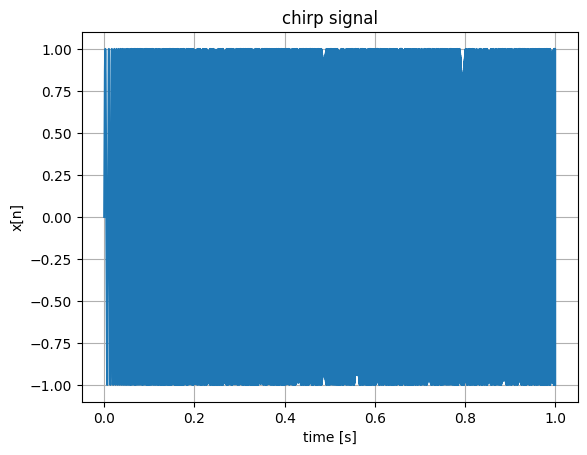

In [2]:
Fs = 16000
f0 = 100
f1 = 4000
T = 1.0
k = (f1 - f0) / T

t = np.arange(0, T, 1/Fs)
x_chirp = np.sin(2*np.pi*(f0*t + 0.5*k*t**2))

print("サンプル数 =", len(x_chirp))
print("k =", k)

plt.figure()
plt.plot(t, x_chirp)
plt.xlabel("time [s]")
plt.ylabel("x[n]")
plt.title("chirp signal")
plt.grid(True)
plt.show()

3. 

$h=(1,-1)$ なので，出力は現在の入力と1サンプル前の入力の差．

\begin{align*}
y[n]=x[n]-x[n-1]
\end{align*}

出力のサンプル数 = 16001


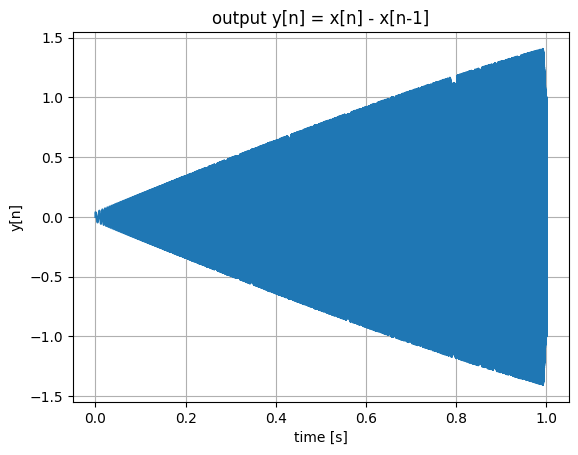

In [3]:
y_chirp = np.convolve(x_chirp, h, mode="full")
t_y = np.arange(len(y_chirp)) / Fs

print("出力のサンプル数 =", len(y_chirp))

plt.figure()
plt.plot(t_y, y_chirp)
plt.xlabel("time [s]")
plt.ylabel("y[n]")
plt.title("output y[n] = x[n] - x[n-1]")
plt.grid(True)
plt.show()

4. 
$h=(1,-1)$ の周波数応答は低周波で小さく，高周波で大きくなります．したがってこのシステムは高域成分を強調します．チャープ信号は時間が進むほど周波数が高くなるため，出力の振幅は後半ほど大きくなりやすいです．

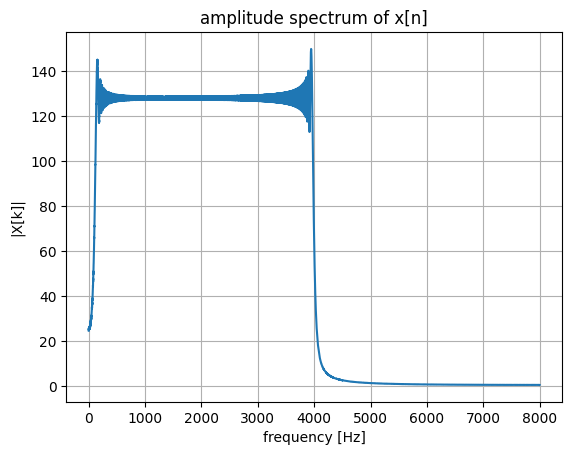

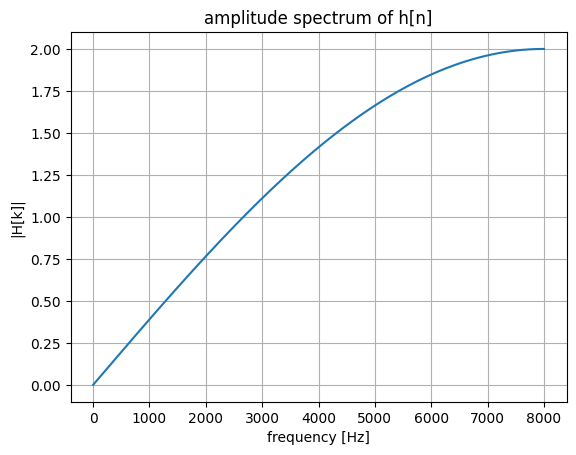

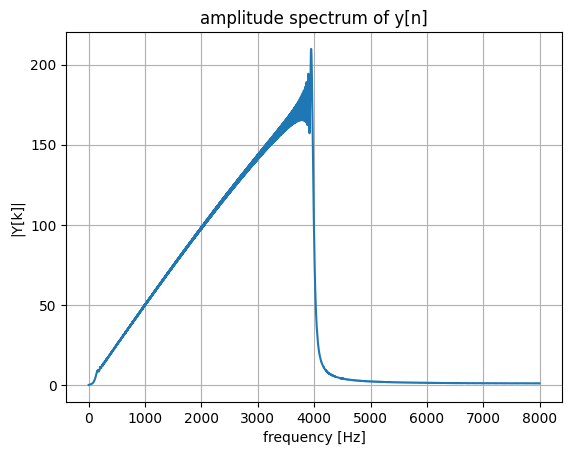

In [4]:
Nfft = 32768
freq = np.fft.rfftfreq(Nfft, d=1/Fs)

X = np.fft.rfft(x_chirp, n=Nfft)
H = np.fft.rfft(h, n=Nfft)
Y = np.fft.rfft(y_chirp, n=Nfft)

plt.figure()
plt.plot(freq, np.abs(X))
plt.xlabel("frequency [Hz]")
plt.ylabel("|X[k]|")
plt.title("amplitude spectrum of x[n]")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(freq, np.abs(H))
plt.xlabel("frequency [Hz]")
plt.ylabel("|H[k]|")
plt.title("amplitude spectrum of h[n]")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(freq, np.abs(Y))
plt.xlabel("frequency [Hz]")
plt.ylabel("|Y[k]|")
plt.title("amplitude spectrum of y[n]")
plt.grid(True)
plt.show()